 Data Loaded Successfully. Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

🔹 K = 1
Accuracy: 0.97
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.

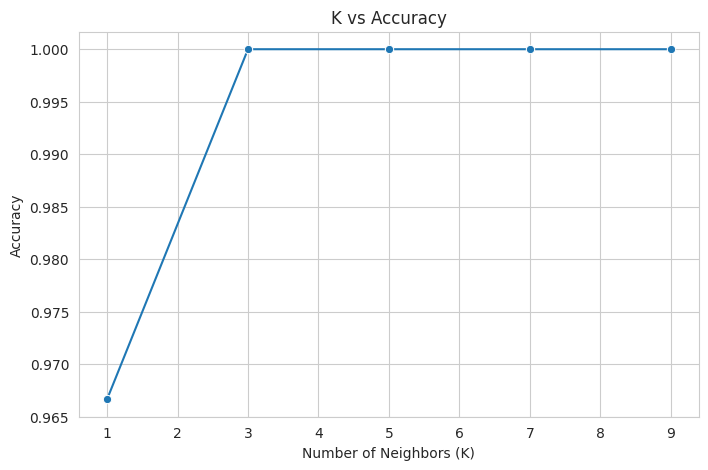

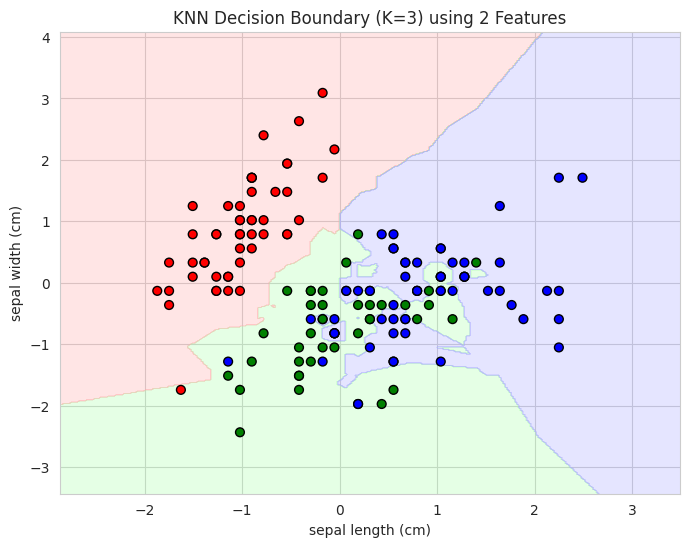


 Task Completed Successfully 


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# ------------------- Load and Preprocess Data ------------------- #
def load_data():
    iris = load_iris()
    X = iris.data
    y = iris.target
    feature_names = iris.feature_names
    df = pd.DataFrame(X, columns=feature_names)
    df['target'] = y
    return df, X, y, feature_names

def normalize_features(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)

def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------- Train and Evaluate Model ------------------- #
def evaluate_knn(X_train, X_test, y_train, y_test, k_values):
    accuracies = []
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

        print(f"\n🔹 K = {k}")
        print("Accuracy:", round(acc, 2))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))
    return accuracies

def plot_k_vs_accuracy(k_values, accuracies):
    plt.figure(figsize=(8, 5))
    sns.lineplot(x=k_values, y=accuracies, marker='o')
    plt.title('K vs Accuracy')
    plt.xlabel('Number of Neighbors (K)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

# ------------------- Decision Boundary Visualization ------------------- #
def plot_decision_boundary(X, y, feature_names, k=3):
    X_vis = X[:, :2]  # Use first 2 features for 2D plot
    X_train, X_test, y_train, y_test = train_test_split(X_vis, y, test_size=0.2, random_state=42)

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap=ListedColormap(['red', 'green', 'blue']), edgecolor='k', s=40)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(f"KNN Decision Boundary (K={k}) using 2 Features")
    plt.show()

# ------------------- Main ------------------- #
def main():
    df, X, y, feature_names = load_data()
    print(" Data Loaded Successfully. Preview:")
    print(df.head())

    X_scaled = normalize_features(X)
    X_train, X_test, y_train, y_test = split_data(X_scaled, y)

    k_values = [1, 3, 5, 7, 9]
    accuracies = evaluate_knn(X_train, X_test, y_train, y_test, k_values)
    plot_k_vs_accuracy(k_values, accuracies)
    plot_decision_boundary(X_scaled, y, feature_names, k=3)

    print("\n Task Completed Successfully ")

# Run the pipeline
main()
